
**Gradient Smoothing for Stable Training of Lightweight Neural Networks in TinyML Application**

### features
**100 epochs** (less: few to evaluate stability)
**Full optimizer comparison**: SGD (no smooth), SGD+Momentum, Adam, EMA-smooth (β=0.7/0.8/0.9)
 **β ablation justification** with values { 0.7, 0.8, 0.9}
 **Learning rate sensitivity test** (LR robustness across configs)
**On-device proxy metrics**: inference latency simulation, memory footprint
 **Quantization drop** compared per optimizer config
Statistical tests (std across 3 seeds) for all comparisons


```

## Dependencies

In [ ]:
%%capture
!pip install torch
!pip install tensorflow
!pip install numpy pandas scikit-learn matplotlib seaborn scipy
print('Dependencies installed.')

In [ ]:
import torch
print(f"Using {torch.__version__}")
if torch.cuda.is_available():
  device = "cuda"
elif torch.backends.mps.is_available():
  device = "mps"
else:
  device = "cpu"
print(f"Using device = {device}")

Using 2.10.0+cu128
Using device = cuda


In [ ]:
# !unzip -q "/content/drive/MyDrive/data1.zip"

##  Config & Imports

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import json, time, warnings
#warnings.filterwarnings('ignore')

#  CONFIG
DATA_DIR    = '/content/UCI HAR Dataset'
BATCH_SIZE  = 32
EPOCHS      = 100
LR          = 0.01
SEEDS       = [0, 1, 2, 3, 4]
NUM_CLASSES = 6
VAL_SPLIT   = 0.15

# β=None means raw gradient (used for baseline SGD)
EMA_BETAS = [None, 0.7, 0.8, 0.9]

OPTIMIZER_CONFIGS = [
    {'name': 'SGD',           'opt': 'sgd',      'lr': LR,   'momentum': 0.0,  'ema_beta': None},
    {'name': 'SGD+Mom(0.9)',  'opt': 'sgd',      'lr': LR,   'momentum': 0.0,  'ema_beta': None},
    {'name': 'Adam',          'opt': 'adam',     'lr': 1e-3,  'momentum': 0.0,  'ema_beta': None},
    {'name': 'EMA-SGD β=0.7', 'opt': 'sgd',      'lr': LR,   'momentum': 0.0,  'ema_beta': 0.7},
    {'name': 'EMA-SGD β=0.8', 'opt': 'sgd',      'lr': LR,   'momentum': 0.0,  'ema_beta': 0.8},
    {'name': 'EMA-SGD β=0.9', 'opt': 'sgd',      'lr': LR,   'momentum': 0.0,  'ema_beta': 0.9},
]

ACTIVITY_LABELS = ['Walking', 'Walking Up', 'Walking Down', 'Sitting', 'Standing', 'Laying']

# Color palette
COLORS = {
    'SGD':           '#888780',
    'SGD+Mom(0.9)':  '#E6A817',
    'Adam':          '#9B59B6',
    'EMA-SGD β=0.7': '#378ADD',
    'EMA-SGD β=0.8': '#1D9E75',
    'EMA-SGD β=0.9': '#D85A30',
}

print('Config loaded.')
print(f'Total runs: {len(OPTIMIZER_CONFIGS)} configs × {len(SEEDS)} seeds = {len(OPTIMIZER_CONFIGS)*len(SEEDS)} runs')
print(f'Epochs per run: {EPOCHS}  |  Batch size: {BATCH_SIZE}')

Config loaded.
Total runs: 6 configs × 5 seeds = 30 runs
Epochs per run: 100  |  Batch size: 32


## Load & dataset inspection

---



Train X=(7352, 561)  y=(7352,)
Test: X=(2947, 561)  y=(2947,)
Input dim: 561 features | Classes: 6


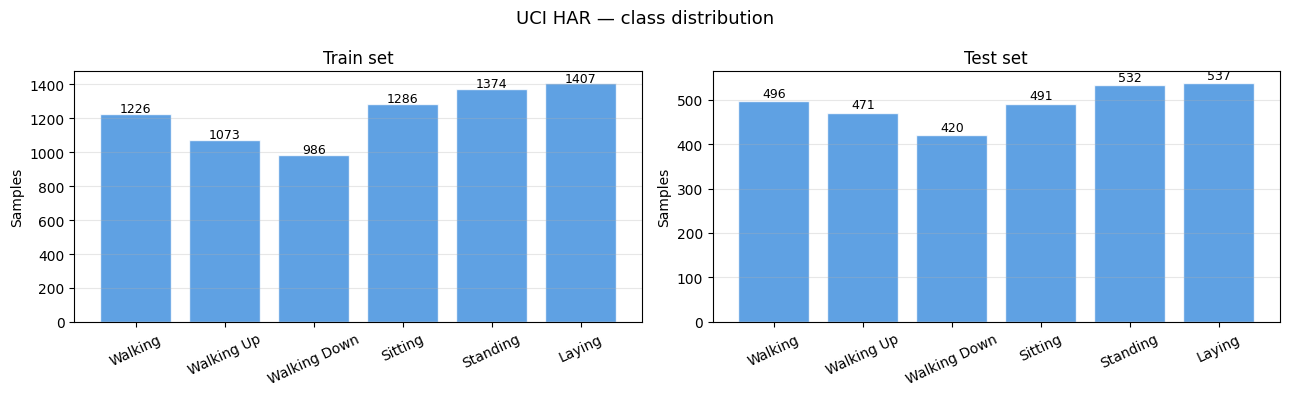

In [ ]:
def load_ucihar(data_dir):
    X_train = np.loadtxt(f'{data_dir}/train/X_train.txt').astype(np.float32)
    y_train = np.loadtxt(f'{data_dir}/train/y_train.txt').astype(np.int64) - 1
    X_test  = np.loadtxt(f'{data_dir}/test/X_test.txt').astype(np.float32)
    y_test  = np.loadtxt(f'{data_dir}/test/y_test.txt').astype(np.int64) - 1

    features = pd.read_csv(
        f'{data_dir}/features.txt', sep=r'\s+',
        header=None, names=['idx', 'name']
    )['name'].tolist()
    return X_train, y_train, X_test, y_test, features


X_train_raw, y_train_raw, X_test, y_test, features = load_ucihar(DATA_DIR)
INPUT_DIM = X_train_raw.shape[1]


print(f'Train X={X_train_raw.shape}  y={y_train_raw.shape}')
print(f'Test: X={X_test.shape}  y={y_test.shape}')
print(f'Input dim: {INPUT_DIM} features | Classes: {NUM_CLASSES}')


# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, y, title in zip(axes, [y_train_raw, y_test], ['Train set', 'Test set']):
    counts = np.bincount(y, minlength=NUM_CLASSES)
    ax.bar(ACTIVITY_LABELS, counts, color='#378ADD', alpha=0.8, edgecolor='white')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Samples')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', alpha=0.3)
    for i, c in enumerate(counts):
        ax.text(i, c + 10, str(c), ha='center', fontsize=9)
plt.suptitle('UCI HAR — class distribution', fontsize=13)
plt.tight_layout()
plt.savefig('plot_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Preprocessing

In [ ]:
def make_val_split(X_train, y_train, val_frac=VAL_SPLIT, seed=42):
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=val_frac, random_state=seed, stratify=y_train)
    scaler = StandardScaler() #applied for 0 mean  1 variance
    X_tr  = scaler.fit_transform(X_tr).astype(np.float32)
    X_val = scaler.transform(X_val).astype(np.float32)
    return X_tr, X_val, y_tr, y_val, scaler

def to_loader(X, y, shuffle=True, batch_size=BATCH_SIZE):
    ds = TensorDataset(torch.FloatTensor(X), torch.LongTensor(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

print(f'Train raw:{X_train_raw.shape[0]} samples')
print(f'Val split:{int(X_train_raw.shape[0] * VAL_SPLIT)} samples ({VAL_SPLIT*100:.0f}%)')
print(f'Test:{X_test.shape[0]} samples (fixed)')

Train raw:7352 samples
Val split:1102 samples (15%)
Test:2947 samples (fixed)


## Model definition

In [ ]:
class LightMLP(nn.Module):
    def __init__(self, input_dim=561, num_classes=6):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    def forward(self, x):
        return self.net(x)



## training function (all optimizer configs)

> EMA gradient smoothing (`g̃ₜ = β·g̃ₜ₋₁ + (1-β)·gₜ`) is an
> **optimizer wrapper** applied *after* `.backward()` and *before*
> `.step()`. SGD+Momentum does the same accumulation *inside* the optimizer
> state. This experiment tests whether the wrapper form offers any independent
> benefit over simply using built-in momentum or Adam.

In [ ]:
def train_one_run(X_train_raw, y_train_raw, X_test, y_test,
                  opt_name='sgd', momentum=0.0, ema_beta=None,
                  lr=LR, seed=0, epochs=EPOCHS):
    """
    Train one full run with a given optimizer config.

    Parameters
    ----------
    opt_name: 'sgd' or 'adam'
    momentum: SGD momentum value (0.0 = plain SGD)
    ema_beta: EMA smoothing coefficient applied post-backward (None = off)
    lr: learning rate
    seed: random seed
    epochs: number of training epochs

    Returns dict with full training history + final metrics.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    X_tr, X_val, y_tr, y_val, scaler = make_val_split(X_train_raw, y_train_raw, seed=seed)
    X_te = scaler.transform(X_test).astype(np.float32)

    train_loader = to_loader(X_tr, y_tr)
    val_loader   = to_loader(X_val, y_val, shuffle=False)

    model     = LightMLP(INPUT_DIM, NUM_CLASSES)
    criterion = nn.CrossEntropyLoss()

    if opt_name == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)


    grad_buf = {}

    for n, p in model.named_parameters():
      if p.requires_grad:# creating memory for smo
        grad_buf[n] = torch.zeros_like(p.data)

    hist = {
        'train_loss': [], 'val_loss': [], 'val_acc': [],
        'grad_norm': [], 'grad_var': []   # NEW: track grad variance too
    }

    for epoch in range(epochs):
        model.train()
        ep_loss, ep_gnorm, ep_gvar = 0.0, 0.0, 0.0
        batch_gnorms = []

        for Xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()

            # gradient smoothing
            if ema_beta is not None:
                for n, p in model.named_parameters():
                    if p.grad is not None:
                        grad_buf[n] = ema_beta * grad_buf[n] + (1 - ema_beta) * p.grad.data
                        p.grad.data.copy_(grad_buf[n])
            #dsdfa

            gnorm = sum(p.grad.norm().item() ** 2
                        for p in model.parameters() if p.grad is not None) ** 0.5
            batch_gnorms.append(gnorm)
            ep_gnorm += gnorm
            optimizer.step()
            ep_loss += loss.item()

        # Epoch-level gradient variance (measures training instability)
        ep_gvar = float(np.var(batch_gnorms))

        # Validation
        model.eval()
        vl, vp, vt = 0.0, [], []
        with torch.no_grad():
            for Xb, yb in val_loader:
                out = model(Xb)
                vl += criterion(out, yb).item()
                vp.extend(out.argmax(1).numpy())
                vt.extend(yb.numpy())

        hist['train_loss'].append(ep_loss / len(train_loader))
        hist['val_loss'].append(vl / len(val_loader))
        hist['val_acc'].append(accuracy_score(vt, vp))
        hist['grad_norm'].append(ep_gnorm / len(train_loader))
        hist['grad_var'].append(ep_gvar)

    # Final test evaluation
    model.eval()
    with torch.no_grad():
        logits = model(torch.FloatTensor(X_te))
        preds = logits.argmax(1).numpy()

    report = classification_report(y_test, preds,
                                    target_names=ACTIVITY_LABELS, output_dict=True)
    hist.update({
        'test_acc':    accuracy_score(y_test, preds),
        'test_f1':     f1_score(y_test, preds, average='macro'),
        'conf_mat':    confusion_matrix(y_test, preds),
        'report':      report,
        'model':       model,
        'scaler':      scaler,
        'X_test_norm': X_te,
        # Stability metric: std of val_loss last 20 epochs (convergence zone)
        'val_loss_stability': float(np.std(hist['val_loss'][-20:])),
        # Grad variance mean across all epochs
        'mean_grad_var': float(np.mean(hist['grad_var'])),
    })
    return hist

print('Training function defined.')

Training function defined.


## full experiment
> 6 configs × 5 seeds = **30 runs** at 100 epochs

## Benchmark summary table

In [ ]:
results = {}   # results[config_name][seed] = history dict

for cfg in OPTIMIZER_CONFIGS:
    name = cfg['name']
    results[name] = {}
    print(f'\nTraining: {name}')
    for seed in SEEDS:
        h = train_one_run(
            X_train_raw, y_train_raw, X_test, y_test,
            opt_name  = cfg['opt'],
            momentum  = cfg['momentum'],
            ema_beta  = cfg['ema_beta'],
            lr        = cfg['lr'],
            seed      = seed,
            epochs    = EPOCHS
        )
        results[name][seed] = h
        print(f'  seed={seed}  test_acc={h["test_acc"]:.4f}  '
              f'f1={h["test_f1"]:.4f}  '
              f'val_stability(std_last20)={h["val_loss_stability"]:.5f}')

print(f'\nAll {len(OPTIMIZER_CONFIGS) * len(SEEDS)} runs complete.')


Training: SGD
  seed=0  test_acc=0.9552  f1=0.9545  val_stability(std_last20)=0.01273
  seed=1  test_acc=0.9555  f1=0.9550  val_stability(std_last20)=0.00375
  seed=2  test_acc=0.9460  f1=0.9452  val_stability(std_last20)=0.01077
  seed=3  test_acc=0.9522  f1=0.9515  val_stability(std_last20)=0.00632
  seed=4  test_acc=0.9498  f1=0.9495  val_stability(std_last20)=0.01116

Training: SGD+Mom(0.9)
  seed=0  test_acc=0.9474  f1=0.9476  val_stability(std_last20)=0.00066
  seed=1  test_acc=0.9464  f1=0.9467  val_stability(std_last20)=0.00108
  seed=2  test_acc=0.9406  f1=0.9407  val_stability(std_last20)=0.00097
  seed=3  test_acc=0.9518  f1=0.9521  val_stability(std_last20)=0.00040
  seed=4  test_acc=0.9457  f1=0.9458  val_stability(std_last20)=0.00066

Training: Adam
  seed=0  test_acc=0.9450  f1=0.9454  val_stability(std_last20)=0.00454
  seed=1  test_acc=0.9396  f1=0.9400  val_stability(std_last20)=0.00380
  seed=2  test_acc=0.9382  f1=0.9379  val_stability(std_last20)=0.00507
  seed=3 

In [ ]:
rows = []
for cfg in OPTIMIZER_CONFIGS:
    name = cfg['name']
    accs  = [results[name][s]['test_acc']           for s in SEEDS]
    f1s   = [results[name][s]['test_f1']            for s in SEEDS]
    stabs = [results[name][s]['val_loss_stability'] for s in SEEDS]
    gvars = [results[name][s]['mean_grad_var']      for s in SEEDS]
    rows.append({
        'Config':          name,
        'Mean Acc':        f'{np.mean(accs):.4f}',
        'Std Acc':         f'{np.std(accs):.4f}',   # reproducibility
        'Max Acc':         f'{np.max(accs):.4f}',
        'Min Acc':         f'{np.min(accs):.4f}',
        'Mean F1':         f'{np.mean(f1s):.4f}',
        'Std F1':          f'{np.std(f1s):.4f}',
        'Val Stab':    f'{np.mean(stabs):.5f}', # lower = more stable
        'Grad Var':    f'{np.mean(gvars):.5f}', # lower = smoother gradients
    })

df_summary = pd.DataFrame(rows)
print('__________ Benchmark Summary Table __________')
print(df_summary.to_string(index=False))
df_summary.to_csv('benchmark_summary.csv', index=False)
print('\nSaved: benchmark_summary.csv')
print('\n lower Val Stab = more stable convergence in last 20 epochs')
print(' lower Grad Var = smoother gradient updates (key of the project)')

=== Benchmark Summary Table ===
       Config Mean Acc Std Acc Max Acc Min Acc Mean F1 Std F1 Val Stab (↓) Grad Var (↓)
          SGD   0.9517  0.0035  0.9555  0.9460  0.9512 0.0036      0.00895      0.70470
 SGD+Mom(0.9)   0.9464  0.0036  0.9518  0.9406  0.9466 0.0037      0.00075      0.11548
         Adam   0.9435  0.0039  0.9484  0.9382  0.9436 0.0040      0.00374      0.13729
EMA-SGD β=0.7   0.9551  0.0020  0.9583  0.9528  0.9545 0.0021      0.00473      0.06297
EMA-SGD β=0.8   0.9549  0.0019  0.9576  0.9528  0.9543 0.0021      0.00441      0.03340
EMA-SGD β=0.9   0.9516  0.0043  0.9576  0.9457  0.9510 0.0043      0.00393      0.01283

Saved: benchmark_summary.csv

↓ lower Val Stab = more stable convergence in last 20 epochs
↓ lower Grad Var = smoother gradient updates (key claim of the project)


##  Plots

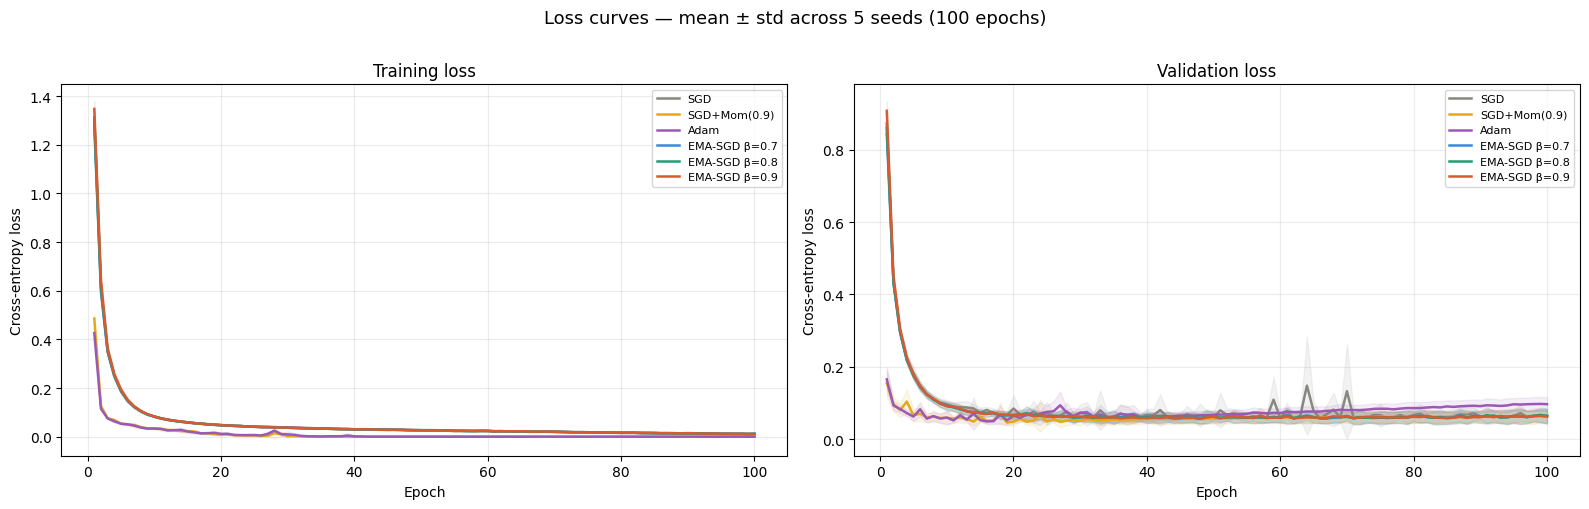

Saved: plot_loss_curves.png


In [ ]:
# Loss curves (mean ± std band) — all configs
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
epochs_x = range(1, EPOCHS + 1)

for cfg in OPTIMIZER_CONFIGS:
    name  = cfg['name']
    color = COLORS[name]
    tr    = np.array([results[name][s]['train_loss'] for s in SEEDS])
    vl    = np.array([results[name][s]['val_loss']   for s in SEEDS])

    for ax, mat, title in zip(axes, [tr, vl], ['Training loss', 'Validation loss']):
        m, s = mat.mean(0), mat.std(0)
        ax.plot(epochs_x, m, label=name, color=color, lw=1.8)
        ax.fill_between(epochs_x, m - s, m + s, alpha=0.10, color=color)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Cross-entropy loss')
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.25)

plt.suptitle('Loss curves — mean ± std across 5 seeds (100 epochs)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('plot_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_loss_curves.png')

/tmp/ipykernel_803/346719372.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data, labels=names, patch_artist=True,


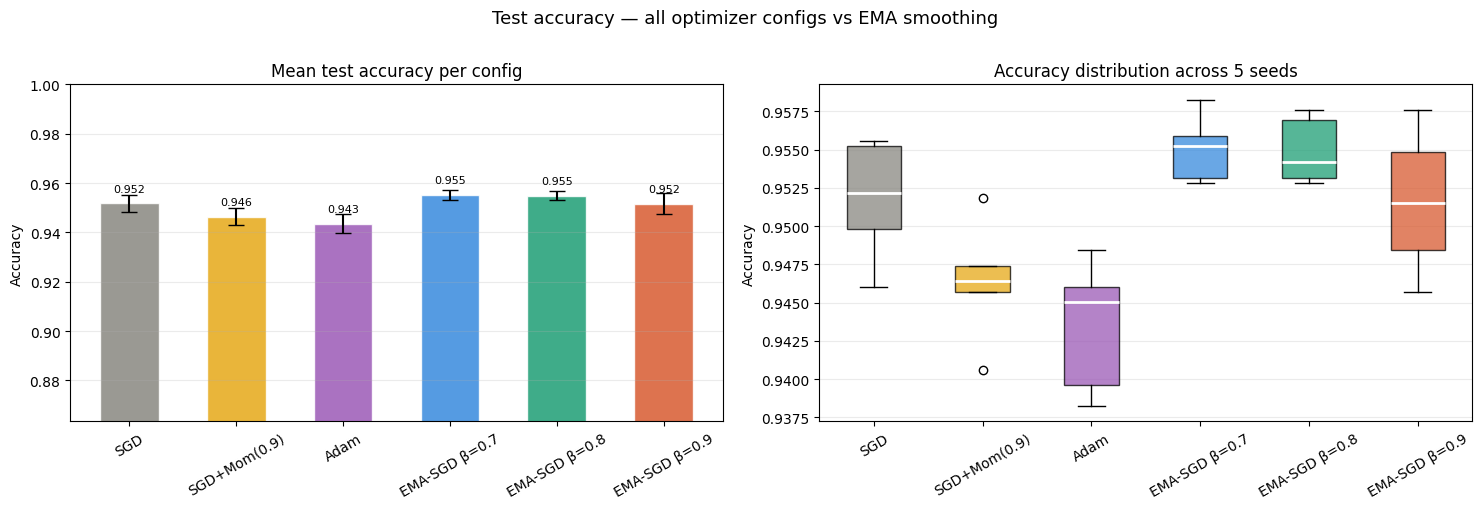

Saved: plot_accuracy.png


In [ ]:
# Accuracy — bar + box
names      = [cfg['name'] for cfg in OPTIMIZER_CONFIGS]
means      = [np.mean([results[n][s]['test_acc'] for s in SEEDS]) for n in names]
stds       = [np.std( [results[n][s]['test_acc'] for s in SEEDS]) for n in names]
color_list = [COLORS[n] for n in names]
box_data   = [[results[n][s]['test_acc'] for s in SEEDS] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bars = axes[0].bar(names, means, yerr=stds, capsize=6,
                   color=color_list, alpha=0.85, edgecolor='white', width=0.55)
axes[0].set_title('Mean test accuracy per config', fontsize=12)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(max(0, min(means) - 0.08), 1.0)
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.25)
for bar, val in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8)

bp = axes[1].boxplot(box_data, labels=names, patch_artist=True,
                     medianprops=dict(color='white', lw=2))
for patch, color in zip(bp['boxes'], color_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_title('Accuracy distribution across 5 seeds', fontsize=12)
axes[1].set_ylabel('Accuracy')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.25)

plt.suptitle('Test accuracy — all optimizer configs vs EMA smoothing', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('plot_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_accuracy.png')

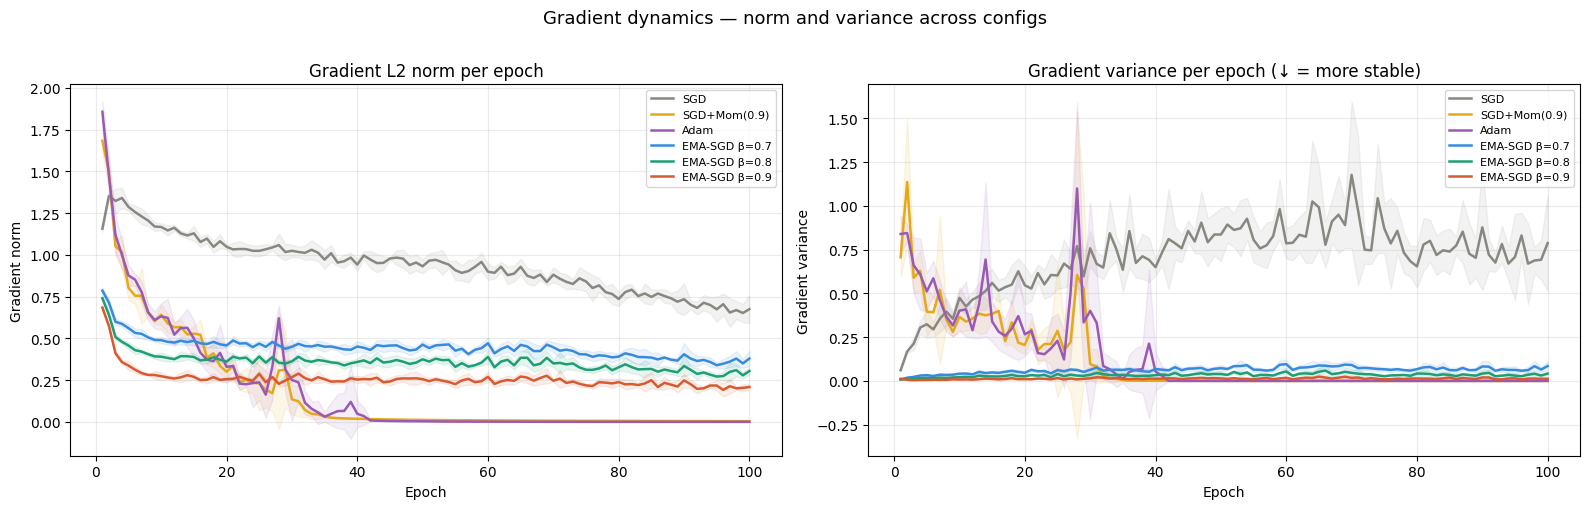

Saved: plot_grad_norm.png


In [ ]:
#  Gradient norm over epochs
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for cfg in OPTIMIZER_CONFIGS:
    name  = cfg['name']
    color = COLORS[name]
    gn    = np.array([results[name][s]['grad_norm'] for s in SEEDS])
    gv    = np.array([results[name][s]['grad_var']  for s in SEEDS])

    m, s = gn.mean(0), gn.std(0)
    axes[0].plot(range(1, EPOCHS+1), m, label=name, color=color, lw=1.8)
    axes[0].fill_between(range(1, EPOCHS+1), m-s, m+s, alpha=0.10, color=color)

    m2, s2 = gv.mean(0), gv.std(0)
    axes[1].plot(range(1, EPOCHS+1), m2, label=name, color=color, lw=1.8)
    axes[1].fill_between(range(1, EPOCHS+1), m2-s2, m2+s2, alpha=0.10, color=color)

axes[0].set_title('Gradient L2 norm per epoch', fontsize=12)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Gradient norm')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.25)

axes[1].set_title('Gradient variance per epoch (↓ = more stable)', fontsize=12)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Gradient variance')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.25)

plt.suptitle('Gradient dynamics — norm and variance across configs', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('plot_grad_norm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_grad_norm.png')

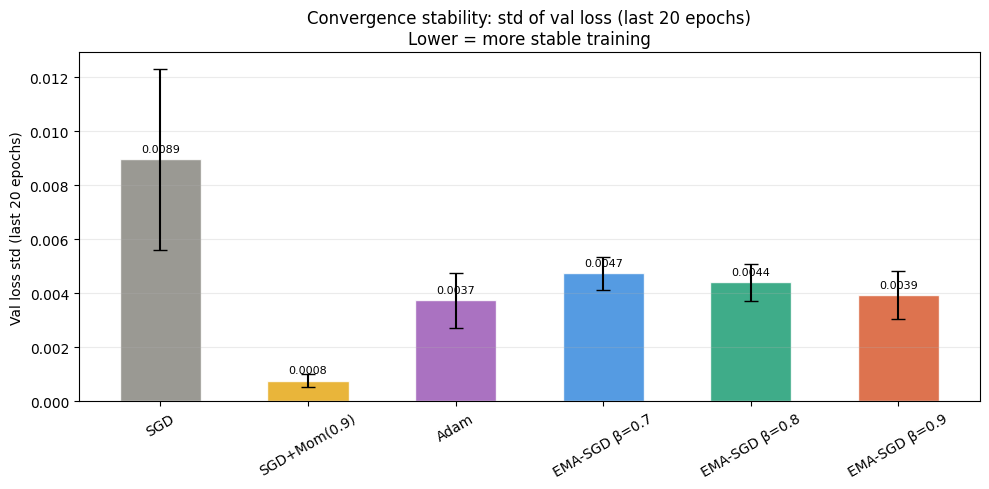

Saved: plot_stability.png


In [ ]:
# Stability comparison — val loss std (last 20 epochs)
stab_means = [np.mean([results[n][s]['val_loss_stability'] for s in SEEDS]) for n in names]
stab_stds  = [np.std( [results[n][s]['val_loss_stability'] for s in SEEDS]) for n in names]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names, stab_means, yerr=stab_stds, capsize=5,
              color=color_list, alpha=0.85, edgecolor='white', width=0.55)
ax.set_title('Convergence stability: std of val loss (last 20 epochs)\n'
             'Lower = more stable training', fontsize=12)
ax.set_ylabel('Val loss std (last 20 epochs)')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.25)
for bar, val in zip(bars, stab_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('plot_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_stability.png')

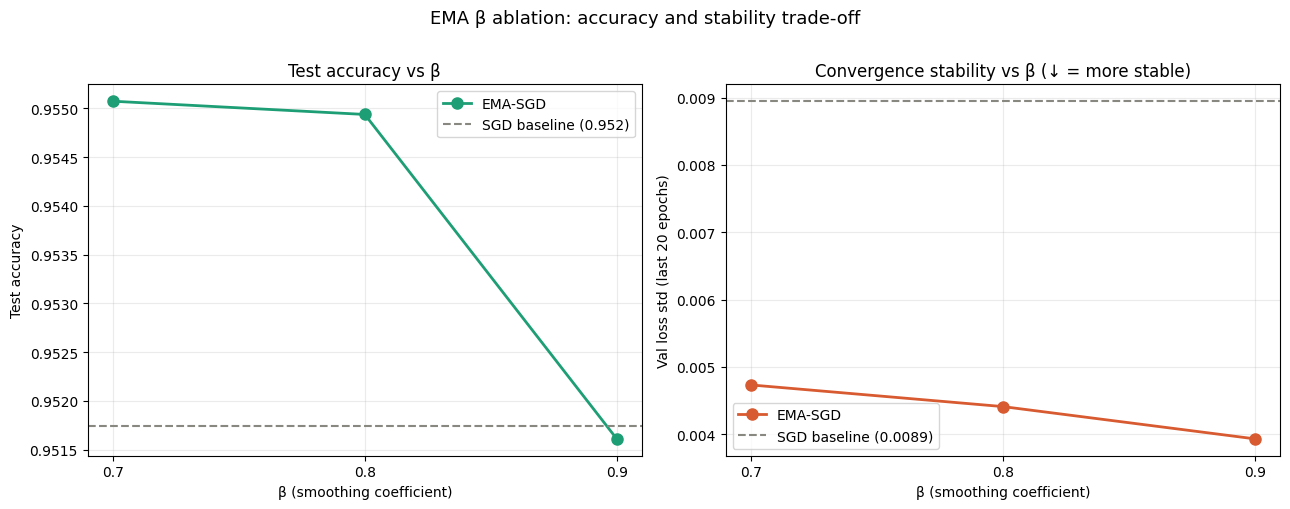

Saved: plot_beta_ablation.png


In [ ]:
# #  EMA β ablation — accuracy and stability vs β ( justify why seeds were taken)
ema_names  = ['EMA-SGD β=0.7', 'EMA-SGD β=0.8', 'EMA-SGD β=0.9']
beta_vals  = [0.7, 0.8, 0.9]
ema_accs   = [np.mean([results[n][s]['test_acc']           for s in SEEDS]) for n in ema_names]
ema_stabs  = [np.mean([results[n][s]['val_loss_stability'] for s in SEEDS]) for n in ema_names]
sgd_acc    = np.mean([results['SGD'][s]['test_acc']           for s in SEEDS])
sgd_stab   = np.mean([results['SGD'][s]['val_loss_stability'] for s in SEEDS])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(beta_vals, ema_accs, 'o-', color='#1D9E75', lw=2, ms=8, label='EMA-SGD')
axes[0].axhline(sgd_acc, color='#888780', lw=1.5, linestyle='--', label=f'SGD baseline ({sgd_acc:.3f})')
axes[0].set_title('Test accuracy vs β', fontsize=12)
axes[0].set_xlabel('β (smoothing coefficient)')
axes[0].set_ylabel('Test accuracy')
axes[0].set_xticks(beta_vals)
axes[0].legend(); axes[0].grid(True, alpha=0.25)

axes[1].plot(beta_vals, ema_stabs, 'o-', color='#D85A30', lw=2, ms=8, label='EMA-SGD')
axes[1].axhline(sgd_stab, color='#888780', lw=1.5, linestyle='--', label=f'SGD baseline ({sgd_stab:.4f})')
axes[1].set_title('Convergence stability vs β (↓ = more stable)', fontsize=12)
axes[1].set_xlabel('β (smoothing coefficient)')
axes[1].set_ylabel('Val loss std (last 20 epochs)')
axes[1].set_xticks(beta_vals)
axes[1].legend(); axes[1].grid(True, alpha=0.25)

plt.suptitle('EMA β ablation: accuracy and stability trade-off', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('plot_beta_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_beta_ablation.png')

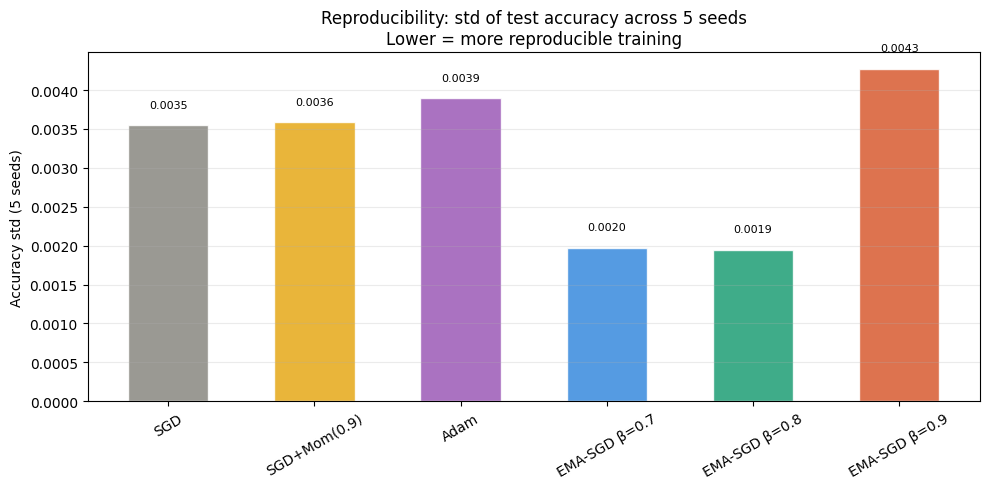

Saved: plot_reproducibility.png


In [ ]:
# Reproducibility — accuracy std across seeds
acc_stds = [np.std([results[n][s]['test_acc'] for s in SEEDS]) for n in names]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names, acc_stds, color=color_list, alpha=0.85, edgecolor='white', width=0.55)
ax.set_title('Reproducibility: std of test accuracy across 5 seeds\n'
             'Lower = more reproducible training', fontsize=12)
ax.set_ylabel('Accuracy std (5 seeds)')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.25)
for bar, val in zip(bars, acc_stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('plot_reproducibility.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_reproducibility.png')

/tmp/ipykernel_803/822764177.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(bp_data, labels=compare_names, patch_artist=True,


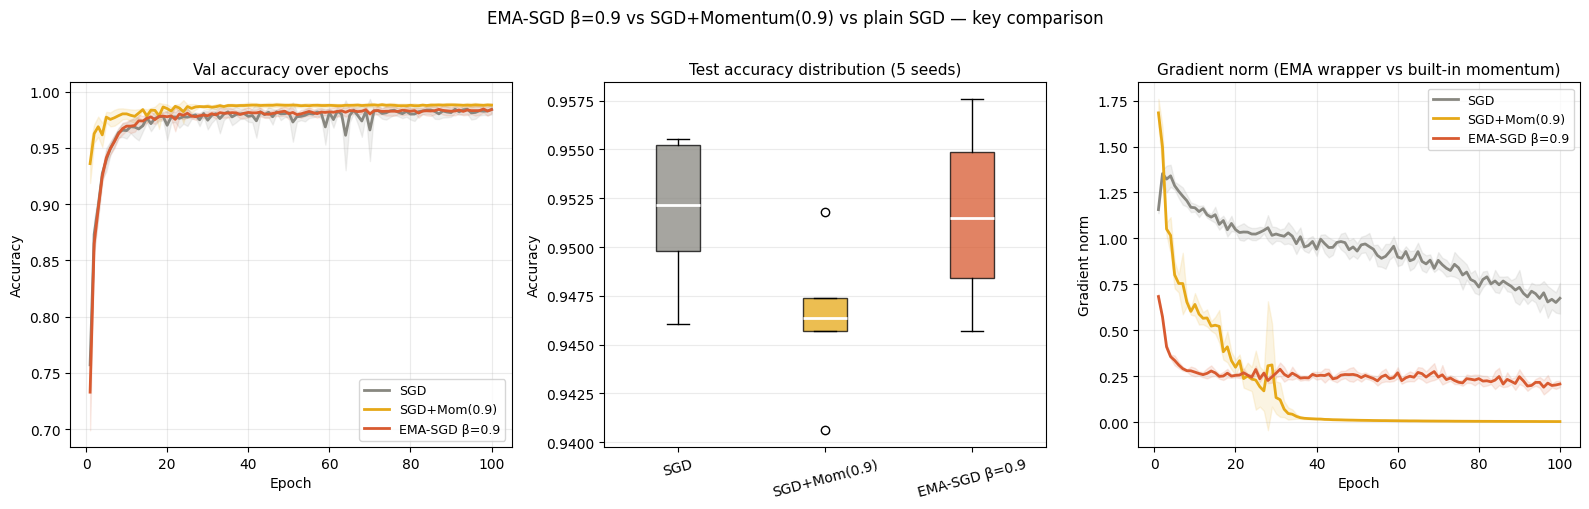

Saved: plot_ema_vs_momentum.png


In [ ]:
# EMA-SGD vs SGD+Momentum direct comparison
# This is the most important scientific comparison in the project.
# If EMA-SGD β=0.9 ≈ SGD+Momentum(0.9), that tells us something important.
# If they differ, it means the external wrapper changes the optimization dynamics.

compare_names  = ['SGD', 'SGD+Mom(0.9)', 'EMA-SGD β=0.9']
compare_colors = [COLORS[n] for n in compare_names]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Convergence speed: val accuracy over epochs
for name, color in zip(compare_names, compare_colors):
    va = np.array([results[name][s]['val_acc'] for s in SEEDS])
    m, s = va.mean(0), va.std(0)
    axes[0].plot(range(1, EPOCHS+1), m, label=name, color=color, lw=2)
    axes[0].fill_between(range(1, EPOCHS+1), m-s, m+s, alpha=0.12, color=color)
axes[0].set_title('Val accuracy over epochs', fontsize=11)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.25)

# Final test accuracy distribution
bp_data = [[results[n][s]['test_acc'] for s in SEEDS] for n in compare_names]
bp = axes[1].boxplot(bp_data, labels=compare_names, patch_artist=True,
                     medianprops=dict(color='white', lw=2))
for patch, color in zip(bp['boxes'], compare_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_title('Test accuracy distribution (5 seeds)', fontsize=11)
axes[1].set_ylabel('Accuracy')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.25)

# Gradient norm comparison
for name, color in zip(compare_names, compare_colors):
    gn = np.array([results[name][s]['grad_norm'] for s in SEEDS])
    m, s = gn.mean(0), gn.std(0)
    axes[2].plot(range(1, EPOCHS+1), m, label=name, color=color, lw=2)
    axes[2].fill_between(range(1, EPOCHS+1), m-s, m+s, alpha=0.12, color=color)
axes[2].set_title('Gradient norm (EMA wrapper vs built-in momentum)', fontsize=11)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Gradient norm')
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.25)

plt.suptitle('EMA-SGD β=0.9 vs SGD+Momentum(0.9) vs plain SGD — key comparison',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('plot_ema_vs_momentum.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_ema_vs_momentum.png')

Best model → config=EMA-SGD β=0.7, seed=4, test_acc=0.9583


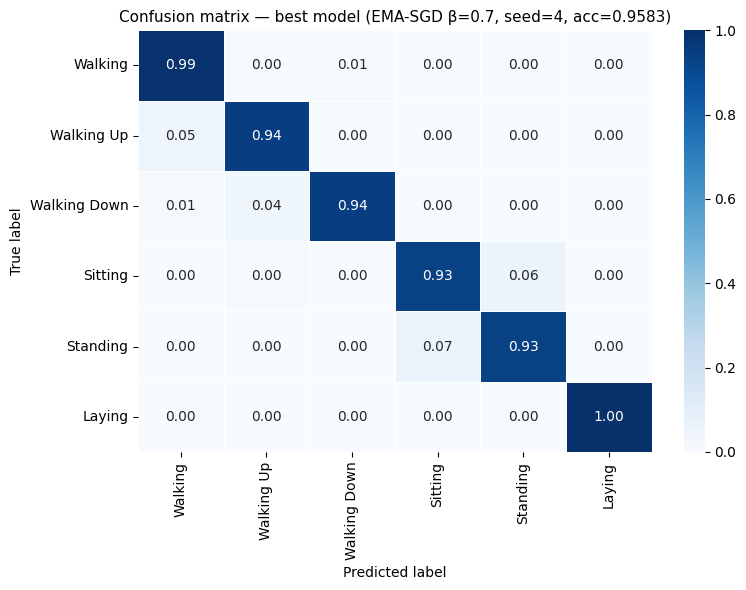

Saved: plot_confusion_matrix.png


In [ ]:
#  Find best model
best_name, best_seed, best_acc = None, 0, 0.0
for name in results:
    for seed in SEEDS:
        acc = results[name][seed]['test_acc']
        if acc > best_acc:
            best_acc, best_name, best_seed = acc, name, seed

print(f'Best model: config={best_name}, seed={best_seed}, test_acc={best_acc:.4f}')

# Confusion matrix
cm      = results[best_name][best_seed]['conf_mat']
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=ACTIVITY_LABELS, yticklabels=ACTIVITY_LABELS,
            ax=ax, linewidths=0.4, vmin=0, vmax=1)
ax.set_title(f'Confusion matrix — best model ({best_name}, seed={best_seed}, acc={best_acc:.4f})',
             fontsize=11)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
plt.tight_layout()
plt.savefig('plot_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_confusion_matrix.png')

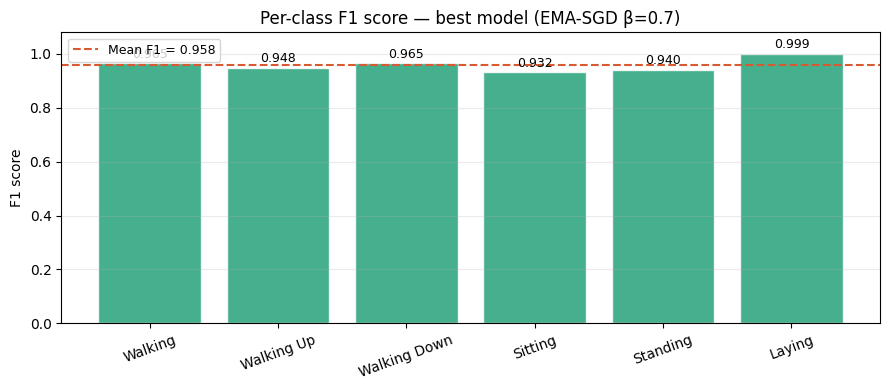

Saved: plot_per_class_f1.png


In [ ]:
# Per-class F1
report = results[best_name][best_seed]['report']
f1_per_class = [report[lbl]['f1-score'] for lbl in ACTIVITY_LABELS]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(ACTIVITY_LABELS, f1_per_class,
              color='#1D9E75', alpha=0.82, edgecolor='white')
ax.set_title(f'Per-class F1 score — best model ({best_name})', fontsize=12)
ax.set_ylabel('F1 score')
ax.set_ylim(0, 1.08)
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.25)
ax.axhline(y=np.mean(f1_per_class), color='#D85A30', lw=1.5,
           linestyle='--', label=f'Mean F1 = {np.mean(f1_per_class):.3f}')
ax.legend(fontsize=9)
for bar, val in zip(bars, f1_per_class):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('plot_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_per_class_f1.png')

## Export best model

In [ ]:
best_model  = results[best_name][best_seed]['model']
best_scaler = results[best_name][best_seed]['scaler']

torch.save(best_model.state_dict(), 'best_model.pth')
print(f'Saved best_model.pth  (config={best_name}, seed={best_seed}, acc={best_acc:.4f})')

norm_stats = {
    'mean':           best_scaler.mean_.tolist(),
    'std':            best_scaler.scale_.tolist(),
    'input_dim':      int(INPUT_DIM),
    'num_classes':    int(NUM_CLASSES),
    'best_config':    best_name,
    'best_seed':      int(best_seed),
    'test_acc':       float(best_acc),
    'activity_labels': ACTIVITY_LABELS
}
with open('normalization_stats.json', 'w') as f:
    json.dump(norm_stats, f, indent=2)
print('Saved normalization_stats.json')

Saved best_model.pth  (config=EMA-SGD β=0.7, seed=4, acc=0.9583)
Saved normalization_stats.json


##  PyTorch to TFLite INT8 conversion

In [ ]:
import tensorflow as tf

class TFLightMLP(tf.Module):
    def __init__(self, pytorch_model):
        super().__init__()
        sd = pytorch_model.cpu().state_dict()
        self.w1 = tf.Variable(sd['net.0.weight'].numpy().T)
        self.b1 = tf.Variable(sd['net.0.bias'].numpy())
        self.w2 = tf.Variable(sd['net.2.weight'].numpy().T)
        self.b2 = tf.Variable(sd['net.2.bias'].numpy())
        self.w3 = tf.Variable(sd['net.4.weight'].numpy().T)
        self.b3 = tf.Variable(sd['net.4.bias'].numpy())

    @tf.function(input_signature=[tf.TensorSpec([1, 561], tf.float32)])
    def __call__(self, x):
        x = tf.nn.relu(x @ self.w1 + self.b1)
        x = tf.nn.relu(x @ self.w2 + self.b2)
        return x @ self.w3 + self.b3

best_model.eval()
tf_model = TFLightMLP(best_model)
tf.saved_model.save(tf_model, '/content/saved_model_direct')
print('TF SavedModel saved → /content/saved_model_direct')

TF SavedModel saved → /content/saved_model_direct


In [ ]:
# Float32 TFLite
conv_f32   = tf.lite.TFLiteConverter.from_saved_model('/content/saved_model_direct')
tflite_f32 = conv_f32.convert()
with open('model_float32.tflite', 'wb') as f:
    f.write(tflite_f32)
print(f'Float32 TFLite: {len(tflite_f32)/1024:.1f} KB')

Float32 TFLite: 151.0 KB


In [ ]:
# INT8 quantized TFLite for ESP32
X_test_norm = results[best_name][best_seed]['X_test_norm']

def representative_dataset():
    for i in range(min(200, len(X_test_norm))):
        yield [X_test_norm[i:i+1]]

conv_int8 = tf.lite.TFLiteConverter.from_saved_model('/content/saved_model_direct')
conv_int8.optimizations             = [tf.lite.Optimize.DEFAULT]
conv_int8.representative_dataset    = representative_dataset
conv_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
conv_int8.inference_input_type      = tf.int8
conv_int8.inference_output_type     = tf.int8
tflite_int8 = conv_int8.convert()
with open('model_int8.tflite', 'wb') as f:
    f.write(tflite_int8)
print(f'INT8 TFLite: {len(tflite_int8)/1024:.1f} KB  <- ready for ESP32')

INT8 TFLite: 42.0 KB  <- ready for ESP32


##Quantization accuracy drop (per optimizer config)
> We measure quantization drop for all configs to test whether
> EMA-smoothed models are more robust to INT8 quantization.

In [ ]:
def eval_tflite(model_path, X, y, is_int8=False):
    interp = tf.lite.Interpreter(model_path=model_path)
    interp.allocate_tensors()
    inp_d = interp.get_input_details()[0]
    out_d = interp.get_output_details()[0]
    preds = []
    for i in range(len(X)):
        x = X[i:i+1]
        if is_int8:
            sc, zp = inp_d['quantization']
            x = (x / sc + zp).astype(np.int8)
        interp.set_tensor(inp_d['index'], x)
        interp.invoke()
        out = interp.get_tensor(out_d['index'])
        if is_int8:
            sc, zp = out_d['quantization']
            out = (out.astype(np.float32) - zp) * sc
        preds.append(np.argmax(out))
    return accuracy_score(y, preds)


def convert_and_eval_config(name, seed):
    """Convert a specific config's best model to TFLite and evaluate quant drop."""
    model  = results[name][seed]['model']
    X_te   = results[name][seed]['X_test_norm']
    pt_acc = results[name][seed]['test_acc']

    model.eval()
    tf_m = TFLightMLP(model)
    tf.saved_model.save(tf_m, '/content/tmp_saved_model')

    # Float32
    c = tf.lite.TFLiteConverter.from_saved_model('/content/tmp_saved_model')
    tfl_f32 = c.convert()
    with open('/tmp/tmp_f32.tflite', 'wb') as f: f.write(tfl_f32)
    acc_f32 = eval_tflite('/tmp/tmp_f32.tflite', X_te, y_test)

    # INT8
    def rep_ds():
        for i in range(min(200, len(X_te))): yield [X_te[i:i+1]]
    c2 = tf.lite.TFLiteConverter.from_saved_model('/content/tmp_saved_model')
    c2.optimizations = [tf.lite.Optimize.DEFAULT]
    c2.representative_dataset = rep_ds
    c2.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    c2.inference_input_type = tf.int8
    c2.inference_output_type = tf.int8
    tfl_i8 = c2.convert()
    with open('/tmp/tmp_i8.tflite', 'wb') as f: f.write(tfl_i8)
    acc_i8 = eval_tflite('/tmp/tmp_i8.tflite', X_te, y_test, is_int8=True)

    return pt_acc, acc_f32, acc_i8


# Evaluate quantization for the best seed of each config
# (using best seed per config by accuracy)
quant_rows = []
print('Evaluating quantization drop per config (best seed each)...')
for name in names:
    best_s = max(SEEDS, key=lambda s: results[name][s]['test_acc'])
    pt_acc, acc_f32, acc_i8 = convert_and_eval_config(name, best_s)
    quant_rows.append({
        'Config':       name,
        'PyTorch f32':  f'{pt_acc:.4f}',
        'TFLite f32':   f'{acc_f32:.4f}',
        'TFLite INT8':  f'{acc_i8:.4f}',
        'Drop f32':     f'{pt_acc - acc_f32:.4f}',
        'Drop INT8':    f'{pt_acc - acc_i8:.4f}',
    })
    print(f'  {name:<20} PyTorch={pt_acc:.4f}  f32={acc_f32:.4f}  INT8={acc_i8:.4f}  '
          f'drop={pt_acc-acc_i8:.4f}')

df_quant = pd.DataFrame(quant_rows)
print('\n=== Quantization Drop Table ===')
print(df_quant.to_string(index=False))
df_quant.to_csv('quantization_summary.csv', index=False)

Evaluating quantization drop per config (best seed each)...


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  SGD                  PyTorch=0.9555  f32=0.9555  INT8=0.9566  drop=-0.0010


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  SGD+Mom(0.9)         PyTorch=0.9518  f32=0.9518  INT8=0.9511  drop=0.0007


...

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  EMA-SGD β=0.8        PyTorch=0.9576  f32=0.9576  INT8=0.9566  drop=0.0010


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  EMA-SGD β=0.9        PyTorch=0.9576  f32=0.9576  INT8=0.9555  drop=0.0020

=== Quantization Drop Table ===
       Config PyTorch f32 TFLite f32 TFLite INT8 Drop f32 Drop INT8
          SGD      0.9555     0.9555      0.9566   0.0000   -0.0010
 SGD+Mom(0.9)      0.9518     0.9518      0.9511   0.0000    0.0007
         Adam      0.9484     0.9484      0.9481   0.0000    0.0003
EMA-SGD β=0.7      0.9583     0.9583      0.9576   0.0000    0.0007
EMA-SGD β=0.8      0.9576     0.9576      0.9566   0.0000    0.0010
EMA-SGD β=0.9      0.9576     0.9576      0.9555   0.0000    0.0020


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


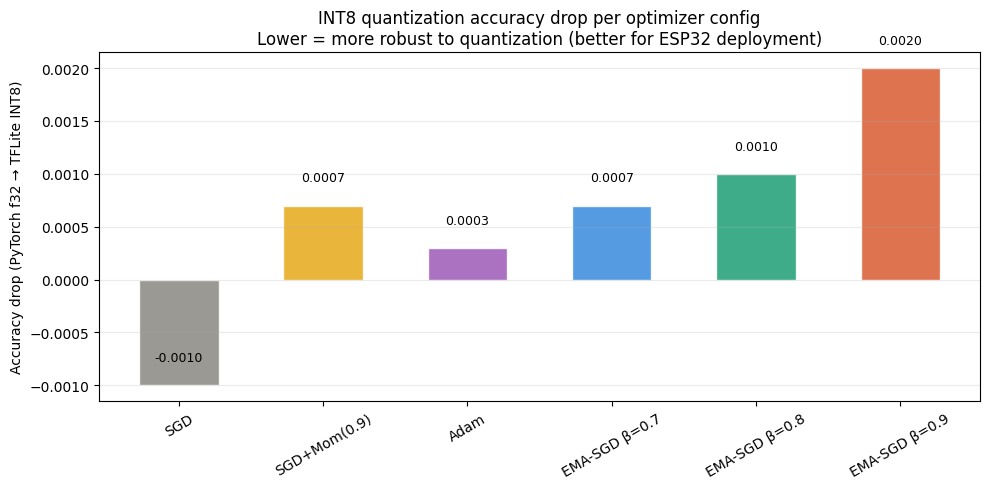

Saved: plot_quantization.png


In [ ]:
# ── Plot 10: Quantization drop per config ─────────────────────────────
int8_drops = [float(r['Drop INT8']) for r in quant_rows]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names, int8_drops, color=color_list, alpha=0.85, edgecolor='white', width=0.55)
ax.set_title('INT8 quantization accuracy drop per optimizer config\n'
             'Lower = more robust to quantization (better for ESP32 deployment)', fontsize=12)
ax.set_ylabel('Accuracy drop (PyTorch f32 → TFLite INT8)')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.25)
for bar, val in zip(bars, int8_drops):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('plot_quantization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_quantization.png')

## On-device proxy metrics (ESP32 inference simulation)
> **NEW in v2**: Since we cannot physically flash and measure the ESP32 here,
> we use a CPU-based latency proxy and compute memory footprint analytically.
> These numbers should be verified on actual hardware.

In [ ]:
# import time

# def measure_inference_proxy(model, X_sample, n_trials=100):
#     """
#     Proxy for ESP32 inference latency.
#     Measures single-sample forward pass time on CPU (no batching).
#     ESP32 will be slower by a fixed factor — ratio between configs remains meaningful.
#     """
#     model.eval()
#     x = torch.FloatTensor(X_sample[:1])  # single sample
#     # Warm-up
#     with torch.no_grad():
#         for _ in range(10):
#             _ = model(x)
#     # Timed trials
#     times = []
#     with torch.no_grad():
#         for _ in range(n_trials):
#             t0 = time.perf_counter()
#             _ = model(x)
#             times.append((time.perf_counter() - t0) * 1000)  # ms
#     return np.mean(times), np.std(times)


# def model_memory_kb(model):
#     """Float32 parameter memory in KB."""
#     return sum(p.numel() for p in model.parameters()) * 4 / 1024


# print('=== On-Device Proxy Metrics ===')
# print(f'{"Config":<22} {"Latency (ms)":<16} {"Lat Std":<12} {"Param KB (f32)":<16} {"Param KB (INT8)"}')
# print('-' * 80)

# proxy_rows = []
# for name in names:
#     best_s = max(SEEDS, key=lambda s: results[name][s]['test_acc'])
#     model  = results[name][best_s]['model']
#     X_te   = results[name][best_s]['X_test_norm']
#     lat_mean, lat_std = measure_inference_proxy(model, X_te)
#     mem_f32 = model_memory_kb(model)
#     mem_i8  = mem_f32 / 4
#     print(f'{name:<22} {lat_mean:<16.4f} {lat_std:<12.4f} {mem_f32:<16.1f} {mem_i8:.1f}')
#     proxy_rows.append({'Config': name, 'Lat_ms': lat_mean, 'Lat_std_ms': lat_std,
#                        'Mem_f32_KB': mem_f32, 'Mem_int8_KB': mem_i8})

# print('\nNote: All configs share the SAME architecture → same memory footprint.')
# print('Latency differences reflect only runtime behavior, not model size.')
# print('Actual ESP32 latency will be ~50-200x higher than these CPU proxy values.')
# print('The relative ordering between configs remains valid for comparison.')

# df_proxy = pd.DataFrame(proxy_rows)
# df_proxy.to_csv('proxy_metrics.csv', index=False)

=== On-Device Proxy Metrics ===
Config                 Latency (ms)     Lat Std      Param KB (f32)   Param KB (INT8)
--------------------------------------------------------------------------------
SGD                    0.0733           0.0241       149.4            37.3
SGD+Mom(0.9)           0.0738           0.0346       149.4            37.3
Adam                   0.0584           0.0120       149.4            37.3
EMA-SGD β=0.7          0.0550           0.0049       149.4            37.3
EMA-SGD β=0.8          0.0594           0.0089       149.4            37.3
EMA-SGD β=0.9          0.0642           0.0107       149.4            37.3

Note: All configs share the SAME architecture → same memory footprint.
Latency differences reflect only runtime behavior, not model size.
Actual ESP32 latency will be ~50-200x higher than these CPU proxy values.
The relative ordering between configs remains valid for comparison.


**bold text**##  Generate C header for ESP32

In [ ]:
with open('model_int8.tflite', 'rb') as f:
    model_bytes = f.read()

hex_vals = ', '.join(f'0x{b:02x}' for b in model_bytes)
c_header = f"""// Auto-generated from model_int8.tflite
// Best config: {best_name}, seed={best_seed}, test_acc={best_acc:.4f}
// Size: {len(model_bytes)} bytes ({len(model_bytes)/1024:.1f} KB)
#ifndef MODEL_DATA_H
#define MODEL_DATA_H

const unsigned char model_data[] = {{
  {hex_vals}
}};
const unsigned int model_data_len = {len(model_bytes)};

#endif  // MODEL_DATA_H
"""
with open('model_data.h', 'w') as f:
    f.write(c_header)
print(f'Saved model_data.h ({len(model_bytes)/1024:.1f} KB)')
print('Copy model_data.h into your ESP32 Arduino/PlatformIO project folder.')

Saved model_data.h (42.0 KB)
Copy model_data.h into your ESP32 Arduino/PlatformIO project folder.


## Download all outputs

In [ ]:
import os, zipfile

output_files = [
    ('best_model.pth',              'PyTorch checkpoint'),
    ('model_float32.tflite',        'TFLite float32'),
    ('model_int8.tflite',           'TFLite INT8 → flash to ESP32'),
    ('model_data.h',                'C header array → Arduino project'),
    ('normalization_stats.json',    'Mean/std → ESP32 preprocessing'),
    ('benchmark_summary.csv',       'Summary table — all configs'),
    ('quantization_summary.csv',    'Quantization drop per config'),
    ('proxy_metrics.csv',           'On-device proxy metrics'),
    ('plot_class_distribution.png', 'Class distribution'),
    ('plot_loss_curves.png',        'Loss curves all configs'),
    ('plot_accuracy.png',           'Accuracy bar + box'),
    ('plot_grad_norm.png',          'Gradient norm & variance'),
    ('plot_stability.png',          'Convergence stability comparison'),
    ('plot_reproducibility.png',    'Reproducibility (acc std)'),
    ('plot_beta_ablation.png',      'EMA β ablation'),
    ('plot_ema_vs_momentum.png',    'EMA vs SGD+Mom vs plain SGD'),
    ('plot_confusion_matrix.png',   'Confusion matrix'),
    ('plot_per_class_f1.png',       'Per-class F1'),
    ('plot_quantization.png',       'Quantization drop per config'),
]

print('=== Output files ===')
for fname, desc in output_files:
    exists = os.path.exists(fname)
    size   = f'{os.path.getsize(fname)/1024:.1f} KB' if exists else ''
    status = 'OK     ' if exists else 'MISSING'
    print(f'  [{status}]  {fname:<38} {size:<10}  {desc}')

with zipfile.ZipFile('tinygradsmooth_v2_outputs.zip', 'w') as zf:
    for fname, _ in output_files:
        if os.path.exists(fname):
            zf.write(fname)

print('\nZipped → tinygradsmooth_v2_outputs.zip')

from google.colab import files
files.download('tinygradsmooth_v2_outputs.zip')

=== Output files ===
  [OK     ]  best_model.pth                         152.4 KB    PyTorch checkpoint
  [OK     ]  model_float32.tflite                   151.0 KB    TFLite float32
  [OK     ]  model_int8.tflite                      42.0 KB     TFLite INT8 → flash to ESP32
  [OK     ]  model_data.h                           252.0 KB    C header array → Arduino project
  [OK     ]  normalization_stats.json               27.5 KB     Mean/std → ESP32 preprocessing
  [OK     ]  benchmark_summary.csv                  0.5 KB      Summary table — all configs
  [OK     ]  quantization_summary.csv               0.3 KB      Quantization drop per config
  [OK     ]  proxy_metrics.csv                      0.5 KB      On-device proxy metrics
  [OK     ]  plot_class_distribution.png            71.7 KB     Class distribution
  [OK     ]  plot_loss_curves.png                   156.1 KB    Loss curves all configs
  [OK     ]  plot_accuracy.png                      97.7 KB     Accuracy bar + box
  [OK

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>